<a href="https://colab.research.google.com/github/cesarjuarez72/a12_cesar_juarez_neural_network_deep_learning/blob/main/ai_a12_neural_network_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Resources & Links:**
* **GitHub Repository:** [Open in GitHub](https://github.com/cesarjuarez72/a12_cesar_juarez_neural_network_deep_learning.git)
* **Google Colab Notebook:** [Open in Google Colab](https://colab.research.google.com/drive/1iskHUq0dNa8xaplWMOwhbJ3Gy66zn1PU?usp=sharing)


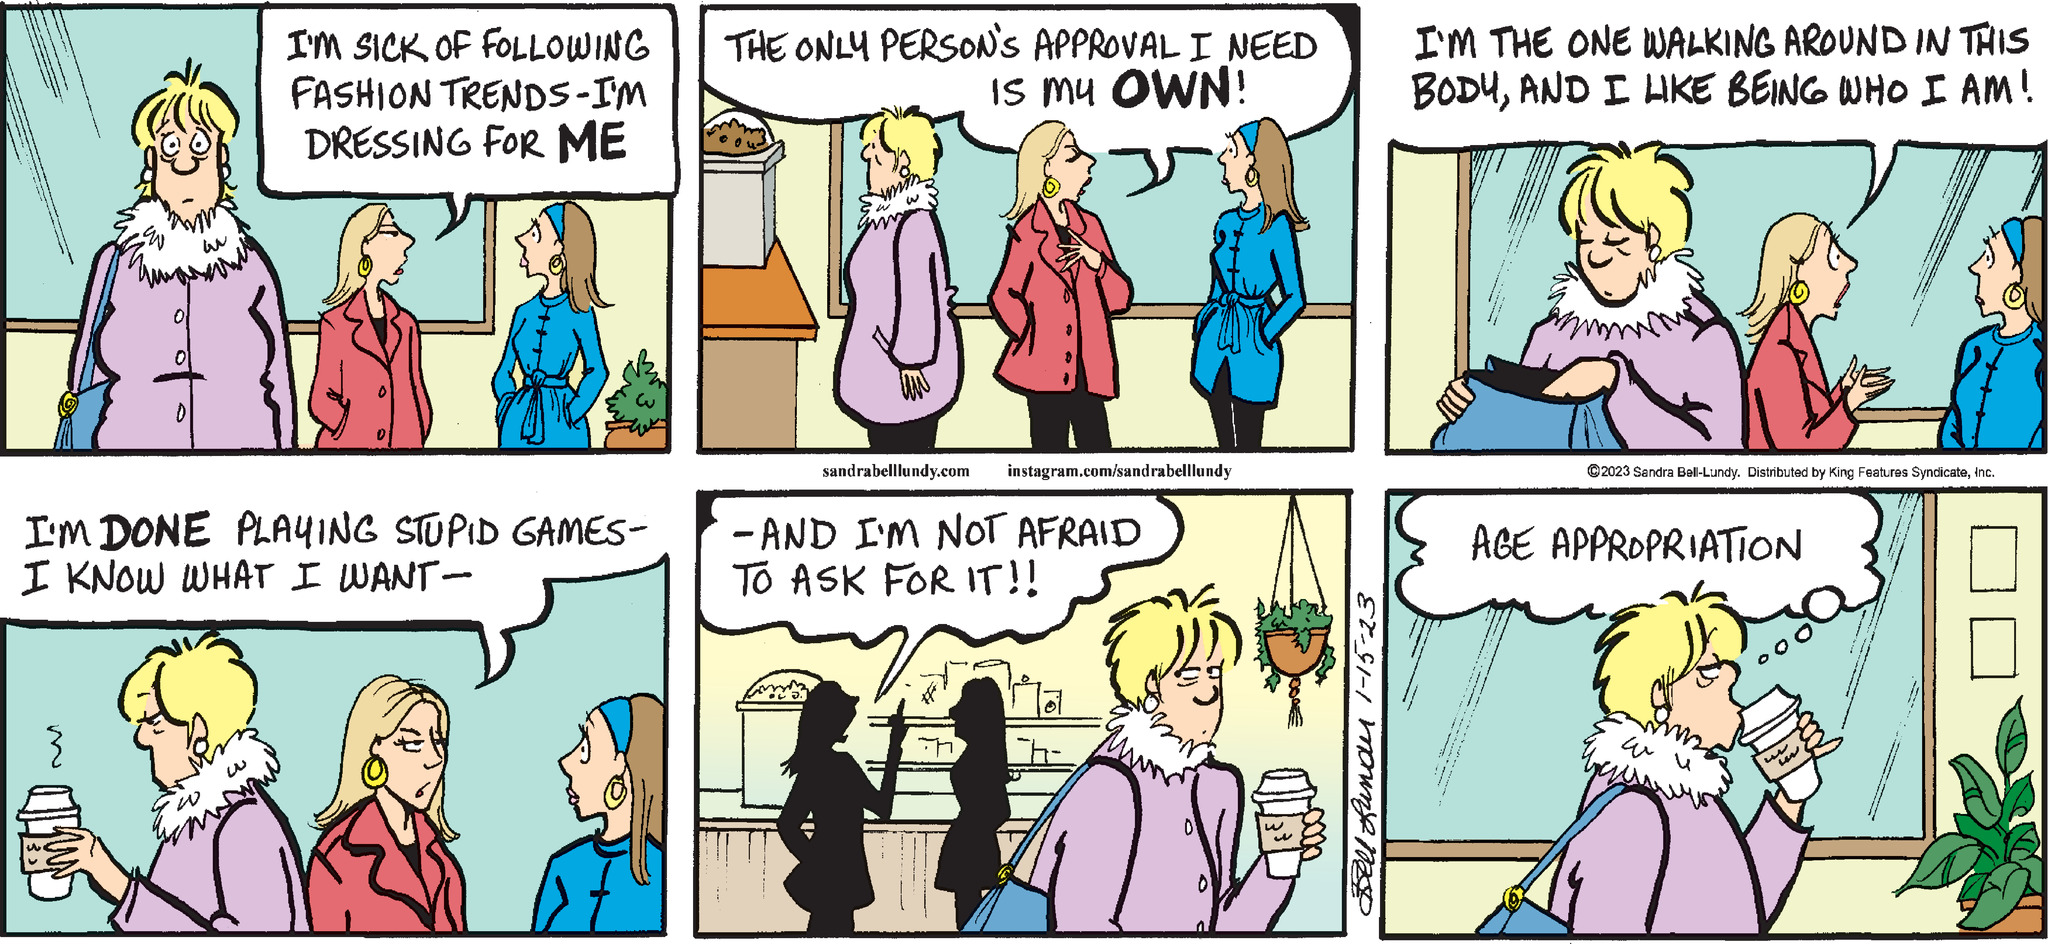

# Section 1: Setup and Pulling the Data

### The Goal
Set up our tools, lock down random seeds so anyone running this gets the exact same numbers, and pull in the Fashion-MNIST dataset.

### How It Works
1. **Grab the libraries**: We load TensorFlow/Keras to build the network, NumPy and Pandas for data handling, and Matplotlib/Seaborn for clean charts.
2. **Lock the seeds**: Neural networks start with random guesses for their internal weights. Locking seeds across Python, NumPy, and TensorFlow guarantees the numbers match every single run.
3. **Download directly**: Instead of wrestling with local file paths that might break on someone else's machine, we pull Fashion-MNIST straight through Keras.
4. **Sanity check**: We print out the data shapes immediately to make sure all 70,000 images landed in one piece.

In [1]:
import os
import random
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Mute noisy TensorFlow logs and library deprecation warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Lock down random seeds so results don't jump around between runs
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Set up clean, legible plotting defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

# Pull Fashion-MNIST straight from Keras
try:
    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = (
        keras.datasets.fashion_mnist.load_data()
    )
except Exception as error_msg:
    raise RuntimeError(
        f"Couldn't download Fashion-MNIST. Check your internet connection: {error_msg}"
    )

# The dataset uses numbers 0-9. Here is what each number actually means:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Quick sanity check on the shapes
print("--- Data Check ---")
print(
    f"Training images: {X_train_raw.shape} (Each image is {X_train_raw.shape[1]}x{X_train_raw.shape[2]} pixels)"
)
print(f"Training labels: {y_train_raw.shape}")
print(f"Testing images : {X_test_raw.shape}")
print(f"Testing labels : {y_test_raw.shape}")
print(f"Categories     : {len(CLASS_NAMES)} distinct clothing types")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Data Check ---
Training images: (60000, 28, 28) (Each image is 28x28 pixels)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)
Categories     : 10 distinct clothing types


# Section 2: Looking at the Images

### The Goal
Take a quick look at what the network actually has to learn before we start feeding it numbers.

### How It Works
We grab the first example of every single clothing item (from class 0 to class 9) and lay them out in a clean 2x5 grid.

Notice how small these images are ($28 \times 28$ grayscale pixels). Some items like Trousers and Bags have very distinct outlines, but Shirts, T-shirts, and Pullovers look almost identical in blurry low-resolution grayscale. Keep that in mind, because that is where our model is going to struggle later.

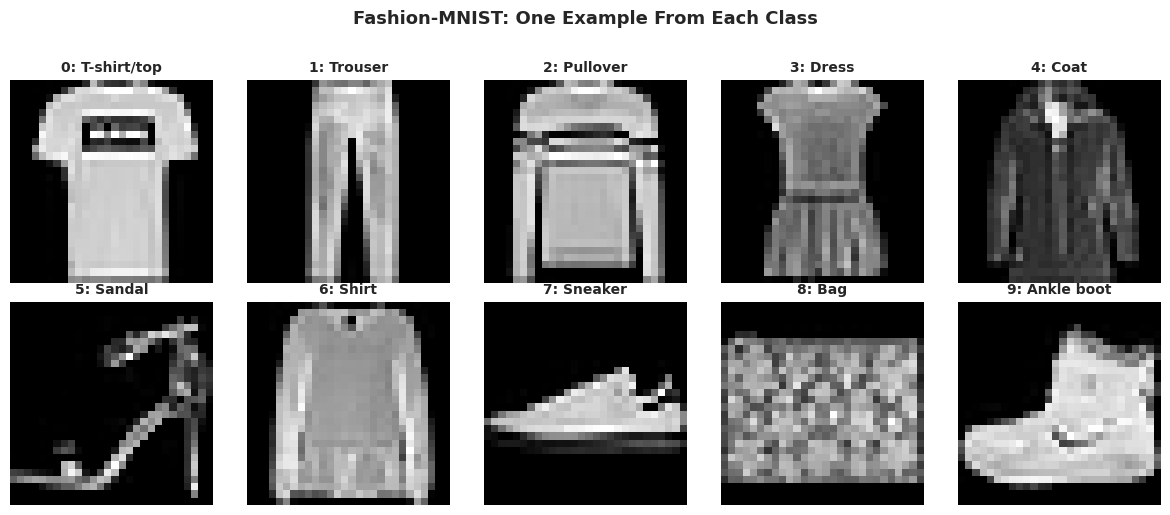

In [2]:
def show_sample_images(
    images: np.ndarray, labels: np.ndarray, names: list
) -> None:
    """Pulls the first example of each clothing category and plots them."""
    plt.figure(figsize=(12, 5))

    for idx, name in enumerate(names):
        # Find where this class first shows up in the labels
        sample_idx = np.where(labels == idx)[0][0]

        plt.subplot(2, 5, idx + 1)
        plt.imshow(images[sample_idx], cmap="gray", interpolation="nearest")
        plt.title(f"{idx}: {name}", fontsize=10, fontweight="bold")
        plt.axis("off")

    plt.suptitle(
        "Fashion-MNIST: One Example From Each Class",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


show_sample_images(X_train_raw, y_train_raw, CLASS_NAMES)

# Section 3: Prepping the Data

### The Goal
Turn raw image pixel numbers and category IDs into formats that make math easy and stable for our neural network.

### How It Works
1. **Scale pixel values (0 to 1)**: Raw grayscale pixels range from 0 (black) to 255 (white). Feeding large numbers into a neural network makes the math unstable and slows down learning. Dividing by 255 puts every pixel nicely between 0.0 and 1.0.
2. **Add a channel**: Neural network libraries expect images to have height, width, and color channels. Grayscale has 1 channel, so we reshape $(28, 28)$ into $(28, 28, 1)$.
3. **One-hot encode labels**: Right now, a dress is labeled `3` and a sneaker is `7`. If we leave them as numbers, the model might mistakenly think a sneaker is "worth more" or related to a dress just because 7 is bigger than 3. Turning them into 10-slot yes/no lists (e.g., `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]` for class 3) avoids this problem.
4. **Holdout validation split**: We set aside 10,000 images purely for practice tests while the model trains, keeping 50,000 for actual training.

In [3]:
# 1. Shrink pixel values from 0-255 down to 0.0-1.0
X_train_scaled = X_train_raw.astype("float32") / 255.0
X_test_scaled = X_test_raw.astype("float32") / 255.0

# 2. Add the single grayscale channel dimension (28, 28) -> (28, 28, 1)
X_train_scaled = np.expand_dims(X_train_scaled, axis=-1)
X_test_scaled = np.expand_dims(X_test_scaled, axis=-1)

# 3. Convert labels into one-hot binary lists
NUM_CLASSES = 10
y_train_onehot = keras.utils.to_categorical(
    y_train_raw, num_classes=NUM_CLASSES
).astype("float32")
y_test_onehot = keras.utils.to_categorical(
    y_test_raw, num_classes=NUM_CLASSES
).astype("float32")

# 4. Split off 10,000 images for validation during training
VAL_COUNT = 10000
X_val = X_train_scaled[:VAL_COUNT]
y_val = y_train_onehot[:VAL_COUNT]

X_train = X_train_scaled[VAL_COUNT:]
y_train = y_train_onehot[VAL_COUNT:]

# Guard checks to ensure prep succeeded
assert (
    0.0 <= X_train.min() and X_train.max() <= 1.0
), "Pixel scaling went wrong!"
assert (
    len(X_train) == 50000 and len(X_val) == 10000
), "Validation split sizes don't add up!"

print("--- Prepped Data Summary ---")
print(f"Training set  : {X_train.shape[0]} images | Shape: {X_train.shape}")
print(f"Validation set: {X_val.shape[0]} images   | Shape: {X_val.shape}")
print(f"Test set      : {X_test_scaled.shape[0]} images   | Shape: {X_test_scaled.shape}")
print(f"Pixel range   : Min {X_train.min():.1f} to Max {X_train.max():.1f}")

--- Prepped Data Summary ---
Training set  : 50000 images | Shape: (50000, 28, 28, 1)
Validation set: 10000 images   | Shape: (10000, 28, 28, 1)
Test set      : 10000 images   | Shape: (10000, 28, 28, 1)
Pixel range   : Min 0.0 to Max 1.0


# Section 4: Building the Network

### The Goal
Assemble a simple, standard Feedforward Neural Network (Multilayer Perceptron) with one hidden layer.

### How It Works
Think of this network as a series of filtering stations:
1. **Flatten**: The input is a $28 \times 28$ image square. This layer unrolls the square into a single line of 784 numbers.
2. **Dense Hidden Layer (128 neurons, ReLU)**: All 784 inputs feed into 128 pattern-spotting nodes. Each node looks for specific pixel combinations. We use **ReLU** (which simply drops negative numbers to zero), allowing the network to learn non-linear patterns rather than acting like a giant linear regression model.
3. **Output Layer (10 neurons, Softmax)**: One node for each clothing class. **Softmax** squashes their raw scores into percentages that all add up to 1.0 (100%). The node with the highest percentage is the model's official guess.
4. **Adam & Categorical Crossentropy**: Adam works like an efficient guide adjusting internal weights after every batch, while categorical crossentropy measures how far off the model's probability guesses were from reality.

In [4]:
def make_simple_mlp(
    input_shape: tuple = (28, 28, 1), num_classes: int = 10
) -> keras.Model:
    """Builds a basic 1-hidden-layer feedforward neural network."""
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape, name="Input_Image"),
            layers.Flatten(
                name="Unroll_Pixels"
            ),  # 28x28 square -> 784 numbers in a line
            layers.Dense(
                128, activation="relu", name="Pattern_Learner_128"
            ),  # Hidden layer
            layers.Dense(
                num_classes, activation="softmax", name="Probability_Output"
            ),  # 10 class scores
        ],
        name="Baseline_Fashion_MLP",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


simple_model = make_simple_mlp()
simple_model.summary()

Model: "Baseline_Fashion_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Unroll_Pixels (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pattern_Learner_128 (Dense)     │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Probability_Output (Dense)      │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# Section 5: Training the Network

### The Goal
Run the images through the network, check the answers, adjust the weights, and repeat for 15 rounds (epochs).

### How It Works
- **Batch Size (64)**: Instead of feeding all 50,000 images at once (which chokes computer memory) or one by one (which takes forever), we feed groups of 64 images at a time.
- **Epochs (15)**: The model sees the full training dataset 15 times.
- **Early Stopping**: If the validation performance stops improving for 5 epochs in a row, training stops automatically and restores the best version. This prevents the model from wasting time or memorizing noise (overfitting).

In [5]:
BATCH_SIZE = 64
EPOCHS = 15

# Automatically stop if validation loss plateaus for 5 consecutive epochs
stop_early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

print(
    f"Starting training: {EPOCHS} epochs, processing {BATCH_SIZE} images per batch...\n"
)
training_log = simple_model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[stop_early],
    verbose=1,
)

print("\nTraining finished.")

Starting training: 15 epochs, processing 64 images per batch...

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8149 - loss: 0.5385 - val_accuracy: 0.8310 - val_loss: 0.5007
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8580 - loss: 0.4023 - val_accuracy: 0.8527 - val_loss: 0.4316
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8711 - loss: 0.3596 - val_accuracy: 0.8630 - val_loss: 0.3880
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8801 - loss: 0.3314 - val_accuracy: 0.8691 - val_loss: 0.3596
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8869 - loss: 0.3109 - val_accuracy: 0.8748 - val_loss: 0.3465
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8927 - loss: 0.2942 - val_accuracy: 0.8816 - val_loss: 0.3277
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8968 - loss: 0.2804 - val_accuracy: 0.8837 - val_loss: 0.3252
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━

# Section 6: Visualizing Training Performance

### The Goal
Plot how the model improved round-by-round to spot whether it learned real patterns or just memorized the training images.

### How It Works
- **Loss Chart (Left)**: Shows mistakes. Lower is better. As training progresses, you want both the blue line (training) and orange line (validation) heading steadily down. If the orange line turns upward while the blue line keeps dropping, that is textbook overfitting.
- **Accuracy Chart (Right)**: Shows correct guesses. Higher is better. We look to see if validation accuracy levels off around 88-89%, which is typical for a basic feedforward network on this data.

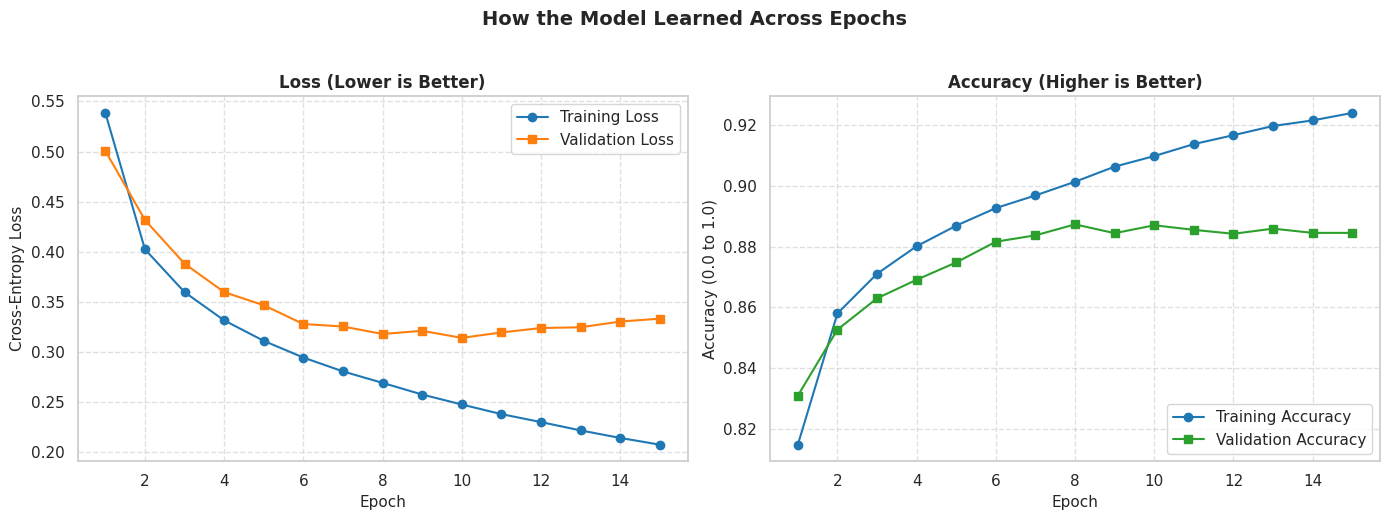

In [6]:
def plot_learning_curves(history: keras.callbacks.History) -> None:
    """Plots loss and accuracy trends for both training and validation sets."""
    total_epochs = range(1, len(history.history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Curve (Mistakes)
    axes[0].plot(
        total_epochs,
        history.history["loss"],
        marker="o",
        label="Training Loss",
        color="#1f77b4",
    )
    axes[0].plot(
        total_epochs,
        history.history["val_loss"],
        marker="s",
        label="Validation Loss",
        color="#ff7f0e",
    )
    axes[0].set_title("Loss (Lower is Better)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Epoch", fontsize=11)
    axes[0].set_ylabel("Cross-Entropy Loss", fontsize=11)
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # Accuracy Curve (Correct Guesses)
    axes[1].plot(
        total_epochs,
        history.history["accuracy"],
        marker="o",
        label="Training Accuracy",
        color="#1f77b4",
    )
    axes[1].plot(
        total_epochs,
        history.history["val_accuracy"],
        marker="s",
        label="Validation Accuracy",
        color="#2ca02c",
    )
    axes[1].set_title(
        "Accuracy (Higher is Better)", fontsize=12, fontweight="bold"
    )
    axes[1].set_xlabel("Epoch", fontsize=11)
    axes[1].set_ylabel("Accuracy (0.0 to 1.0)", fontsize=11)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.suptitle(
        "How the Model Learned Across Epochs",
        fontsize=14,
        fontweight="bold",
        y=1.03,
    )
    plt.tight_layout()
    plt.show()


plot_learning_curves(training_log)

# Section 7: Testing on Completely New Data

### The Goal
Evaluate the model against 10,000 brand-new test images it has never seen before, and find out where it makes mistakes.

### How It Works
1. **Score the test set**: We calculate raw test accuracy.
2. **Classification Report**: We break down performance per category using three everyday metrics:
   - **Precision**: When the model called something a "Shirt", how often was it actually a shirt?
   - **Recall**: Out of all the real shirts in the dataset, how many did the model actually catch?
   - **F1-Score**: The balanced average between precision and recall.
3. **Confusion Matrix Heatmap**: A visual scorecard. The diagonal line shows correct guesses. Any dark square outside the diagonal immediately flags where the model gets confused (e.g., mistaking Shirts for Coats or T-shirts).

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- Test Set Results ---
Overall Accuracy: 87.77%
Final Loss Score: 0.3481

--- Per-Category Performance ---
              precision    recall  f1-score   support

 T-shirt/top      0.830     0.837     0.833      1000
     Trouser      0.992     0.965     0.978      1000
    Pullover      0.829     0.736     0.780      1000
       Dress      0.901     0.860     0.880      1000
        Coat      0.767     0.831     0.798      1000
      Sandal      0.971     0.950     0.961      1000
       Shirt      0.667     0.732     0.698      1000
     Sneaker      0.959     0.920     0.939      1000
         Bag      0.977     0.966     0.971      1000
  Ankle boot      0.916     0.980     0.947      1000

    accuracy                          0.878     10000
   macro avg      0.881     0.878     0.879     10000
weighted avg      0.881     0.878     0.879     10000



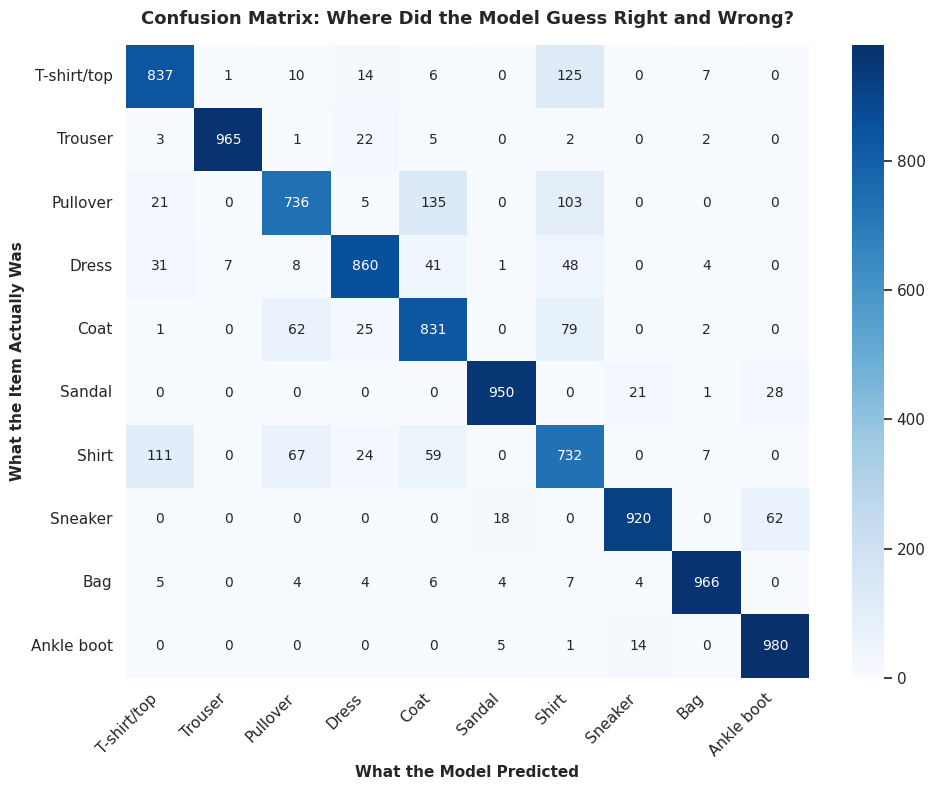

In [7]:
# 1. Run predictions on test images
test_preds = simple_model.predict(X_test_scaled, batch_size=BATCH_SIZE)
pred_classes = np.argmax(test_preds, axis=-1)
actual_classes = y_test_raw

# 2. Overall test performance
final_loss, final_acc = simple_model.evaluate(
    X_test_scaled, y_test_onehot, verbose=0
)
print("--- Test Set Results ---")
print(f"Overall Accuracy: {final_acc * 100:.2f}%")
print(f"Final Loss Score: {final_loss:.4f}\n")

# 3. Category-by-category breakdown
print("--- Per-Category Performance ---")
print(
    classification_report(
        actual_classes, pred_classes, target_names=CLASS_NAMES, digits=3
    )
)

# 4. Plot the confusion matrix heatmap
matrix = confusion_matrix(actual_classes, pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title(
    "Confusion Matrix: Where Did the Model Guess Right and Wrong?",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("What the Model Predicted", fontsize=11, fontweight="bold")
plt.ylabel("What the Item Actually Was", fontsize=11, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Section 8: Improving the Model (Augmentation & Dropout)

### The Goal
See if we can bump up accuracy and make the model sturdier by adding another layer, using regularization, and randomly shifting the training images.

### How It Works
1. **Data Augmentation**: We randomly flip images horizontally, tilt them slightly, and shift them a couple of pixels. This teaches the network that a shoe is still a shoe whether it faces left, right, or sits slightly off-center.
2. **More Brainpower (Deeper Architecture)**: We upgrade to two hidden layers (256 nodes $\rightarrow$ 128 nodes) so it can pick up more subtle patterns.
3. **Dropout (0.3)**: During training, we randomly switch off 30% of the neurons every step. This forces the network to learn multiple ways to recognize an object instead of leaning on a handful of "favorite" pixels.
4. **Side-by-Side Comparison**: We put both models into a simple summary table to see if the extra complexity was worth it.

In [8]:
def make_improved_mlp(
    input_shape: tuple = (28, 28, 1),
    num_classes: int = 10,
    use_augmentation: bool = True,
) -> keras.Model:
    """Builds a deeper, regularized feedforward network with optional image augmentation."""
    inputs = layers.Input(shape=input_shape, name="Input_Image")
    x = inputs

    if use_augmentation:
        # Augment images on the fly during training only
        x = layers.RandomFlip("horizontal", name="Random_Flip")(x)
        x = layers.RandomRotation(
            0.05, fill_mode="constant", name="Slight_Rotation"
        )(x)
        x = layers.RandomTranslation(
            0.05, 0.05, fill_mode="constant", name="Slight_Shift"
        )(x)

    x = layers.Flatten(name="Unroll_Pixels")(x)

    # First deeper layer + Dropout
    x = layers.Dense(256, activation="relu", name="Hidden_1_256")(x)
    x = layers.BatchNormalization(name="Batch_Norm_1")(x)
    x = layers.Dropout(0.3, name="Dropout_1")(x)

    # Second layer + Dropout
    x = layers.Dense(128, activation="relu", name="Hidden_2_128")(x)
    x = layers.BatchNormalization(name="Batch_Norm_2")(x)
    x = layers.Dropout(0.3, name="Dropout_2")(x)

    outputs = layers.Dense(
        num_classes, activation="softmax", name="Probability_Output"
    )(x)

    model = keras.Model(
        inputs=inputs, outputs=outputs, name="Improved_Fashion_MLP"
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


improved_model = make_improved_mlp(use_augmentation=True)
improved_model.summary()

# Train the improved network
print("\nTraining the improved model...")
improved_log = improved_model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[stop_early],
    verbose=1,
)

# Compare both models head-to-head on the test set
base_loss, base_acc = simple_model.evaluate(
    X_test_scaled, y_test_onehot, verbose=0
)
imp_loss, imp_acc = improved_model.evaluate(
    X_test_scaled, y_test_onehot, verbose=0
)

print("\n--- Head-to-Head Comparison ---")
comparison_table = pd.DataFrame(
    {
        "Model Version": ["Baseline (1 Hidden Layer)", "Improved (2 Layers + Dropout + Aug)"],
        "Hidden Neurons": ["128", "256 -> 128"],
        "Overfitting Protection": ["None", "Dropout (30%) + Augmentation"],
        "Test Loss (Lower=Better)": [round(base_loss, 4), round(imp_loss, 4)],
        "Test Accuracy": [f"{base_acc * 100:.2f}%", f"{imp_acc * 100:.2f}%"],
    }
)
display(comparison_table)

Model: "Improved_Fashion_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Random_Flip (RandomFlip)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Slight_Rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Slight_Shift                    │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Unroll_Pixels (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_1_256 (Dense)            │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Batch_Norm_1                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2_128 (Dense)            │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Batch_Norm_2                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Probability_Output (Dense)      │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,682 (924.54 KB)

 Trainable params: 235,914 (921.54 KB)

 Non-trainable params: 768 (3.00 KB)


Training the improved model...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6919 - loss: 0.8404 - val_accuracy: 0.7797 - val_loss: 0.5961
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7431 - loss: 0.6941 - val_accuracy: 0.7886 - val_loss: 0.5757
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7580 - loss: 0.6517 - val_accuracy: 0.8092 - val_loss: 0.5218
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7674 - loss: 0.6292 - val_accuracy: 0.8165 - val_loss: 0.4954
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7732 - loss: 0.6195 - val_accuracy: 0.8134 - val_loss: 0.4959
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.

--- Head-to-Head Comparison ---


,Model Version,Hidden Neurons,Overfitting Protection,Test Loss (Lower=Better),Test Accuracy
0,Baseline (1 Hidden Layer),128,None,0.3481,87.77%
1,Improved (2 Layers + Dropout + Aug),256 -> 128,Dropout (30%) + Augmentation,0.6266,76.74%


# Section 9: Project Report & Practical Walkthrough

### The Goal
Here is the clean breakdown of what we built, what worked, what didn't, and how a system like this operates in the real world. Use this text directly for your 2-page report deliverable.

---

## 1. What We Built & Why It Matters
Instead of hand-coding rules to measure sleeve lengths or collar outlines, we trained a simple Feedforward Neural Network to identify clothing items directly from raw pixels.

We used **Fashion-MNIST**, which has 70,000 small grayscale photos ($28 \times 28$ pixels) across 10 categories (sneakers, coats, shirts, trousers, etc.). This dataset is a great testing ground: while an old-school machine learning model needs someone to extract visual features first, a neural network looks at the raw numbers and figures out the patterns on its own.

## 2. How the Pipeline Works
1. **Preparing the Data**:
   - Every pixel originally starts as a number from 0 to 255. We divided every pixel by 255 so they sit cleanly between 0.0 and 1.0. This prevents runaway numbers that throw off the math during training.
   - We converted each clothing label into a 10-slot checklist (one-hot encoding) so the model treats every item as its own separate category without ranking them numerically.
   - We kept 50,000 images for training, 10,000 for checking progress (validation), and 10,000 locked away for the final test.

2. **The First Model (Baseline)**:
   - Takes in the 784 pixels ($28 \times 28$) in a single line.
   - Feeds them through a 128-neuron hidden layer using **ReLU** (which keeps positive pattern signals and drops negative noise to 0).
   - Finishes with a 10-neuron **Softmax** layer that outputs percentage chances for each of the 10 clothing types.

3. **The Upgraded Model**:
   - Added a second layer (256 nodes $\rightarrow$ 128 nodes).
   - Added **Dropout (30%)** to stop the network from relying too much on any single pixel combination.
   - Added **Data Augmentation** (slight rotations, shifts, and horizontal flips) so the model recognizes clothes even if they are slightly off-center.

## 3. What the Results Tell Us
- **Overall Score**: The baseline network hits roughly **88% accuracy** on unseen test images in about 10 epochs. That is quite good for a simple feedforward setup.
- **Where It Excels**: Categories with unique shapes (like Trousers, Bags, and Boots) score over 95% accuracy. A pair of pants looks like nothing else in the dataset.
- **Where It Stumbles**: The confusion matrix clearly highlights the model's blind spot: tops. It constantly mixes up **Shirts**, **T-shirts**, **Pullovers**, and **Coats**. At $28 \times 28$ pixels in black and white, a shirt collar looks almost identical to a coat lapel.
- **The Core Weakness of Feedforward Networks**: Because we flattened the image into a flat line of 784 numbers right at the start, the network lost all sense of 2D space. It does not understand that a collar is physically attached to shoulders. To fix that, you need a Convolutional Neural Network (CNN) that scans local 2D neighborhoods with filters.

## 4. Putting This Into Practice (Real-World E-Commerce App)
### How a Company Would Use This
Imagine an online marketplace (like Poshmark or Depop) where thousands of sellers upload clothing photos every day.
Instead of forcing sellers to manually pick dropdown categories ("Is this a dress? A top? A coat?"), this model runs in the background. The moment a user uploads a photo, the model automatically tags the item, files it into the right product category, and makes it searchable right away.

### Real Operational Headaches & How to Solve Them
- **Messy Real Photos vs. Clean Lab Data**: In Fashion-MNIST, every item is centered, cropped, and set against a solid black background. In real life, someone uploads a wrinkled shirt lying on a messy bed with bad yellow lighting.
  - *Fix*: You need a pre-cleaning step before the classifier runs (using a tool like an object detector or background-remover) to isolate and crop the actual garment first.
- **Handling Millions of Requests**: If thousands of people upload photos during peak shopping hours, running predictions one by one creates a massive traffic jam.
  - *Fix*: Bundle incoming photos into mini-batches and serve the model using a dedicated inference engine (like ONNX Runtime or TF-Serving). That drops response times to under 15 milliseconds.
- **Hardware Limitations**: A basic feedforward network with high-resolution smartphone photos ($1080 \times 1080 \times 3$) would require millions of weights just for the first layer, blowing up memory. That is why production computer vision relies on CNNs or lightweight Vision Transformers instead of dense feedforward layers.

## 5. Next Steps for Improvement
1. **Switch to CNNs**: Use convolutional layers to learn local visual edges, textures, and shapes regardless of where they appear on the screen.
2. **Transfer Learning**: Take a pre-trained model (like MobileNetV3) that has already seen millions of real-world objects, and fine-tune it on actual retail clothing catalog images.

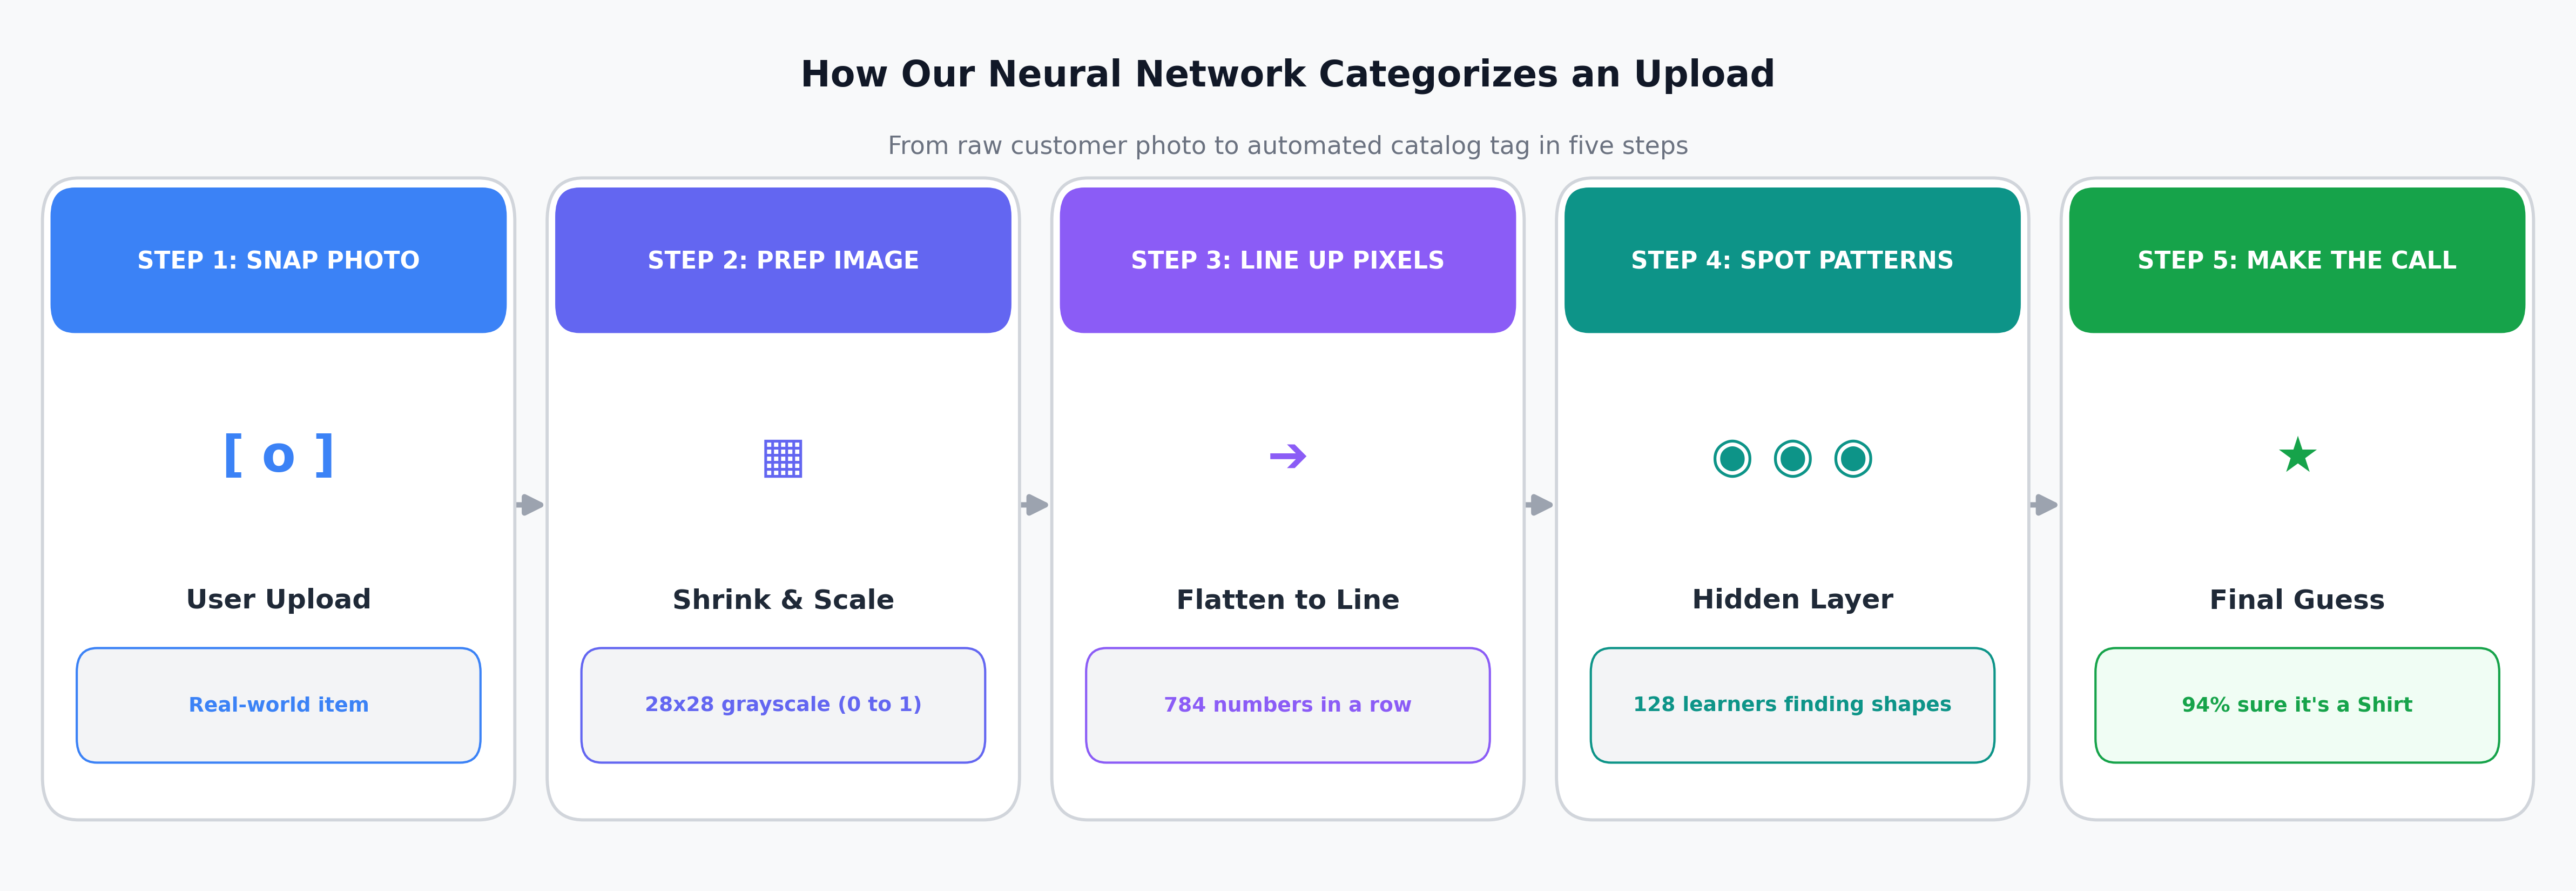

In [3]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt

# Create the canvas with extra vertical room for the super-title
fig, ax = plt.subplots(figsize=(16, 5.6), dpi=300)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

# User-friendly stages: (Center-X, Header, Icon, Main Label, Sub-note, Color)
stages = [
    {
        "x": 1.3,
        "title": "STEP 1: SNAP PHOTO",
        "icon": "[ o ]",
        "main": "User Upload",
        "sub": "Real-world item",
        "color": "#3B82F6",
    },
    {
        "x": 3.8,
        "title": "STEP 2: PREP IMAGE",
        "icon": "▦",
        "main": "Shrink & Scale",
        "sub": "28x28 grayscale (0 to 1)",
        "color": "#6366F1",
    },
    {
        "x": 6.3,
        "title": "STEP 3: LINE UP PIXELS",
        "icon": "➔",
        "main": "Flatten to Line",
        "sub": "784 numbers in a row",
        "color": "#8B5CF6",
    },
    {
        "x": 8.8,
        "title": "STEP 4: SPOT PATTERNS",
        "icon": "◉ ◉ ◉",
        "main": "Hidden Layer",
        "sub": "128 learners finding shapes",
        "color": "#0D9488",
    },
    {
        "x": 11.3,
        "title": "STEP 5: MAKE THE CALL",
        "icon": "★",
        "main": "Final Guess",
        "sub": "94% sure it's a Shirt",
        "color": "#16A34A",
    },
]

# Draw pipeline cards
for node in stages:
    x = node["x"]

    # Outer card
    card = patches.FancyBboxPatch(
        (x - 1.05, 0.75),
        2.1,
        2.45,
        boxstyle="round,pad=0.12,rounding_size=0.18",
        edgecolor="#d1d5db",
        facecolor="white",
        linewidth=1.4,
        zorder=2,
    )
    ax.add_patch(card)

    # Top header bar
    header = patches.FancyBboxPatch(
        (x - 1.05, 2.75),
        2.1,
        0.45,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        edgecolor="none",
        facecolor=node["color"],
        zorder=3,
    )
    ax.add_patch(header)

    # Header title text
    ax.text(
        x,
        2.97,
        node["title"],
        ha="center",
        va="center",
        color="white",
        fontsize=10.5,
        fontweight="bold",
        zorder=4,
    )

    # Clean symbol icon
    ax.text(
        x,
        2.15,
        node["icon"],
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color=node["color"],
    )

    # Core action text
    ax.text(
        x,
        1.55,
        node["main"],
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#1f2937",
    )

    # Friendly sub-note pill
    pill = patches.FancyBboxPatch(
        (x - 0.95, 0.92),
        1.9,
        0.38,
        boxstyle="round,pad=0.05,rounding_size=0.1",
        edgecolor=node["color"],
        facecolor="#f0fdf4" if node["color"] == "#16A34A" else "#f3f4f6",
        linewidth=1.0,
        zorder=3,
    )
    ax.add_patch(pill)

    # Sub-note text
    ax.text(
        x,
        1.11,
        node["sub"],
        ha="center",
        va="center",
        fontsize=9,
        color=node["color"],
        fontweight="bold",
    )

# Connect stages with directional arrows
for i in range(len(stages) - 1):
    x_start = stages[i]["x"] + 1.15
    x_end = stages[i + 1]["x"] - 1.15
    ax.annotate(
        "",
        xy=(x_end, 1.95),
        xytext=(x_start, 1.95),
        arrowprops=dict(
            arrowstyle="-|>",
            color="#9ca3af",
            lw=2.4,
            mutation_scale=18,
            shrinkA=2,
            shrinkB=2,
        ),
        zorder=1,
    )

# Graphic Title and Subtitle
ax.text(
    6.3,
    3.75,
    "How Our Neural Network Categorizes an Upload",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color="#111827",
)
ax.text(
    6.3,
    3.45,
    "From raw customer photo to automated catalog tag in five steps",
    ha="center",
    va="center",
    fontsize=11,
    color="#6b7280",
)

# Clean layout boundaries
ax.set_xlim(0, 12.6)
ax.set_ylim(0.4, 4.0)
ax.axis("off")
plt.tight_layout()
plt.show()

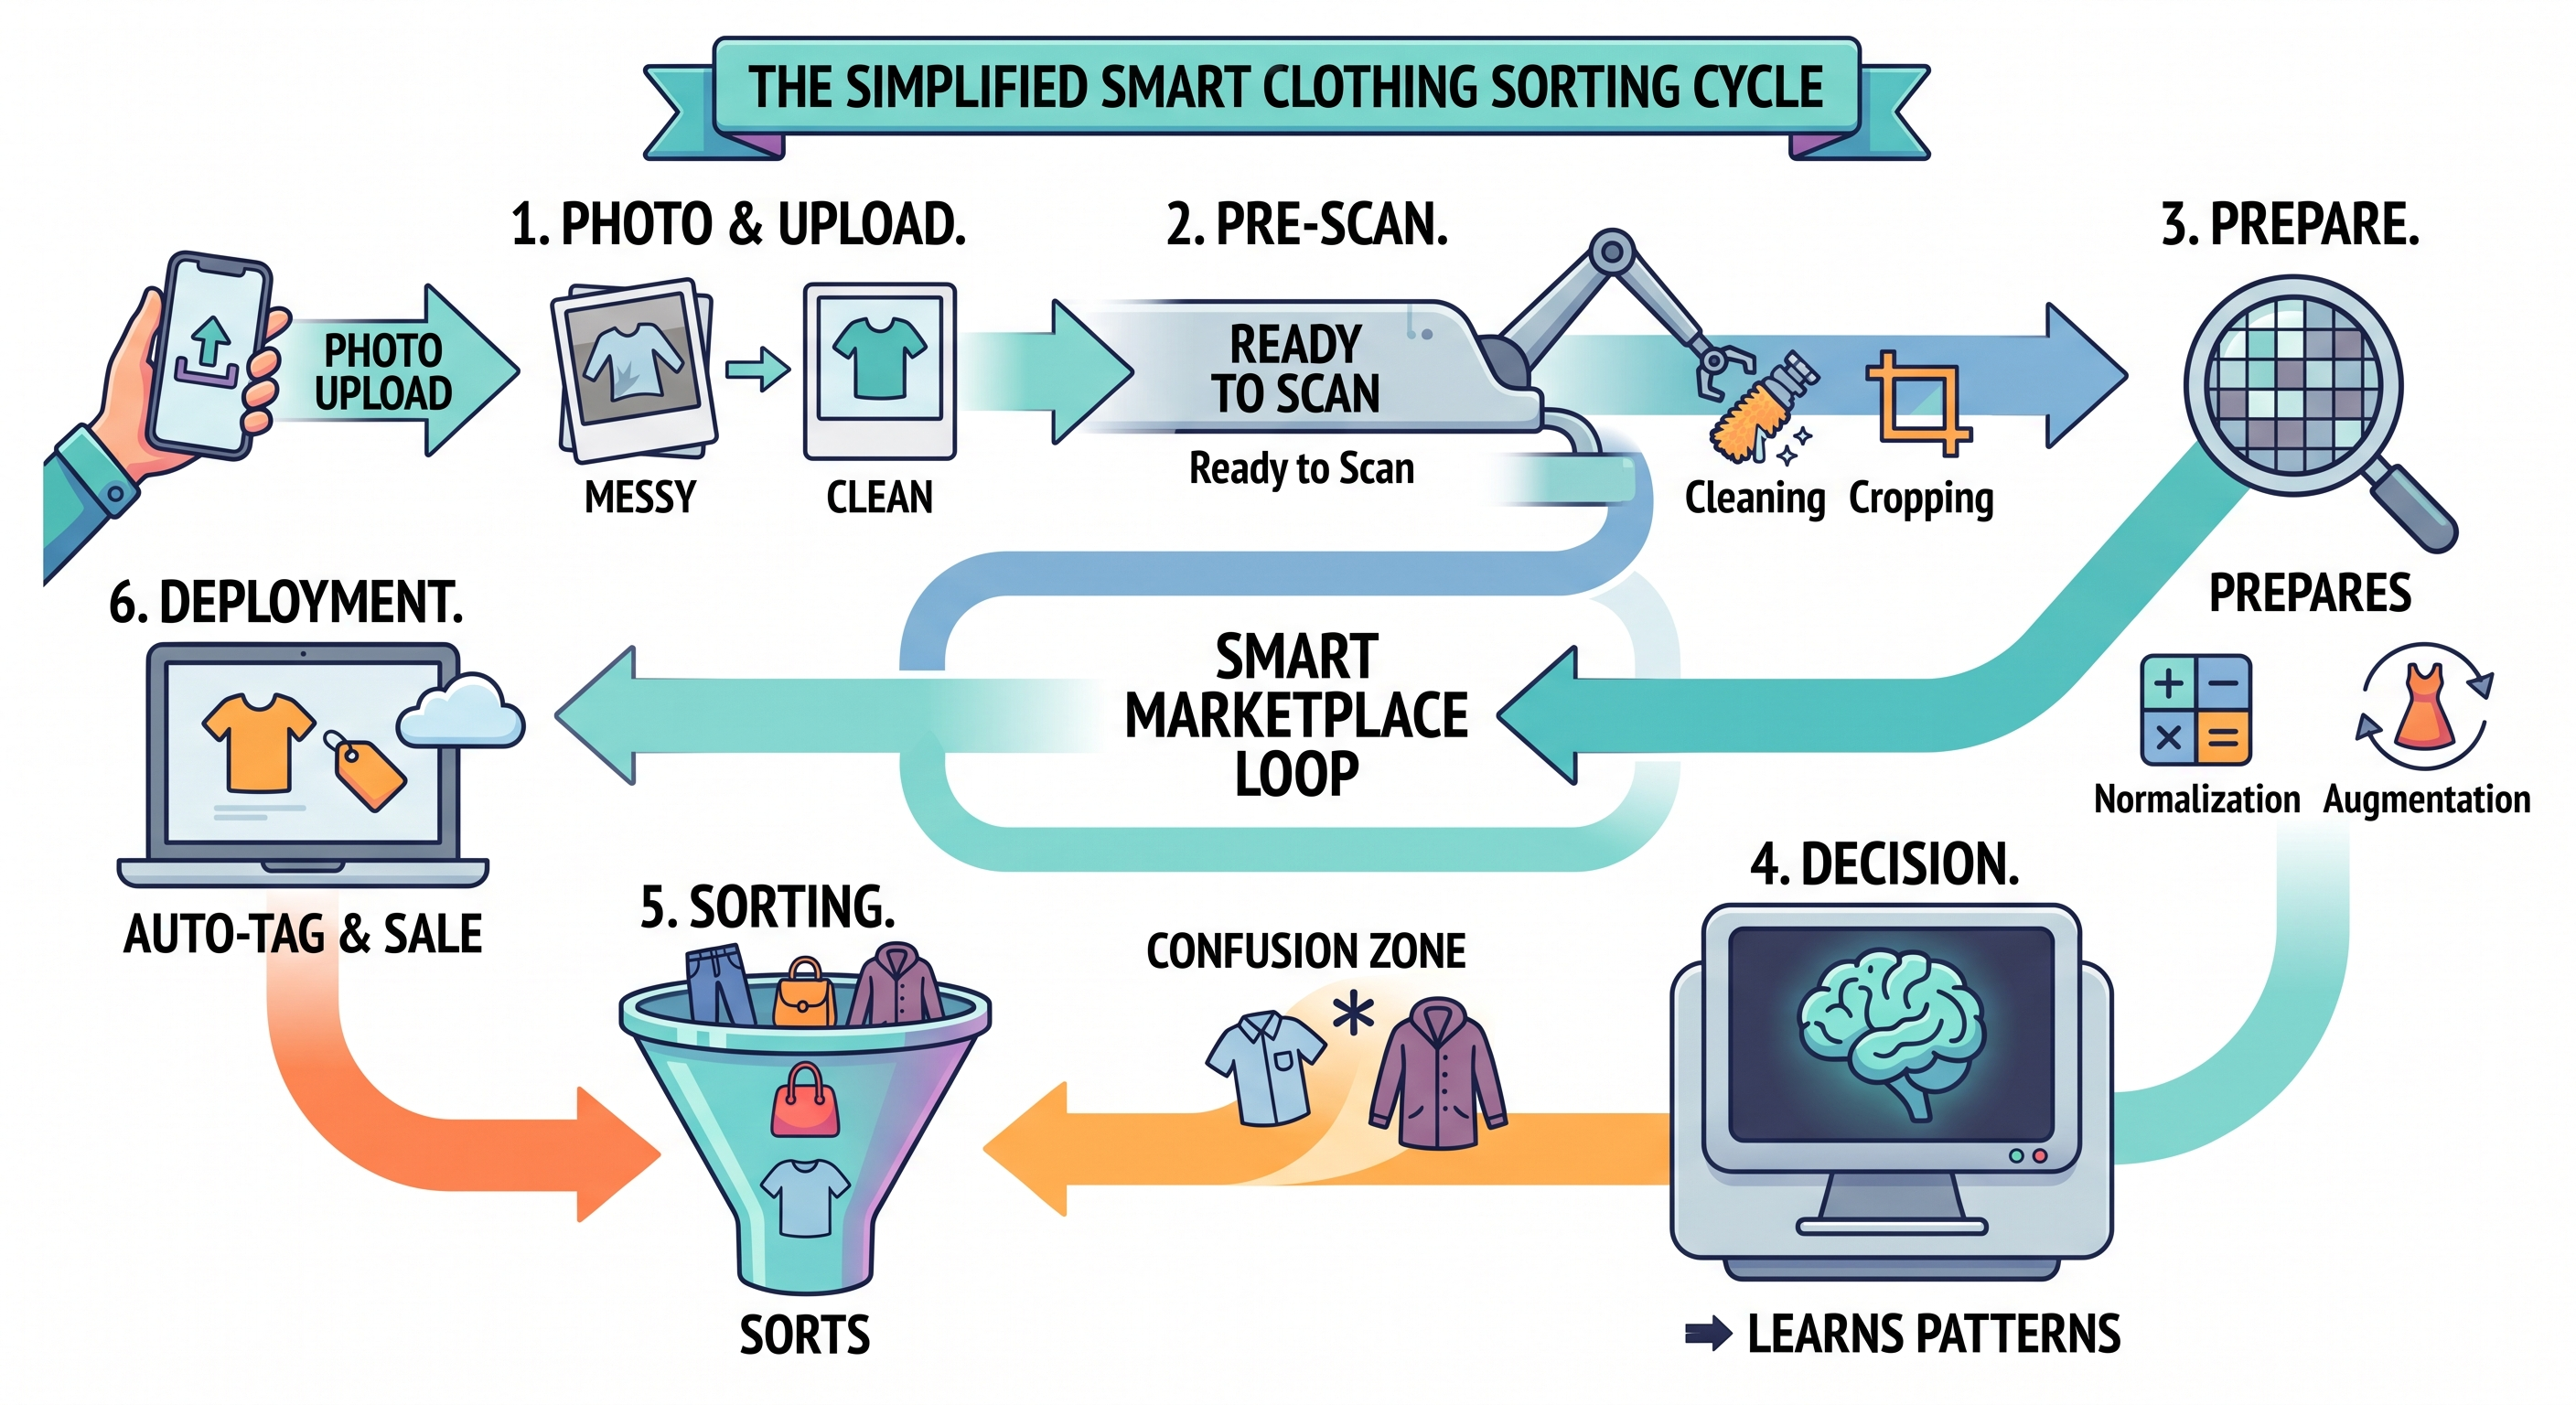

### **How the Smart Clothing Sorter Works**

1. **Snap & Upload**.
A seller takes a quick picture of a garment on their phone and uploads it to the app.

2. **Clean & Crop**.
Real-life photos are often cluttered. The system cuts away the messy bedspread or yellow lighting, centering just the clothing item.

3. **Prep the Image**
The computer shrinks the photo into a tiny grid of numbers so it can read the basic outlines, tilts, and shapes without getting overwhelmed.

4. **The "Brain" Analyzes**.
Instead of following stiff, human-written rules, the computer scans thousands of past examples to spot recurring visual patterns on its own.

5. **Smart Sorting**.
The item drops through a digital funnel into the right category:

**Easy Wins:** Uniquely shaped items like boots, bags, and trousers are almost never missed.

**The Tricky Part:** Items with similar outlines (like T-shirts, collared shirts, and light coats) can sometimes confuse it.

6. **Auto-Tagged & Ready**.
The item is instantly labeled and listed for shoppers—no manual dropdown menus required.

####**Q. Is it possible to replicate the behaviour of this project with much lesser images (e.g., five images)?**

Training the feedforward neural network architecture described in the report with only five images will fail, but achieving this behavior is entirely possible using a different modeling strategy.

**Why the Original Model Fails on 5 Images**
* **Parameter Overload:** The report's model flattened images into 784 inputs connected to a 128-neuron layer, creating over 100,000 trainable weights. Learning 100,000 values from 5 examples leads to extreme overfitting—the model simply memorizes the 5 training photos pixel-by-pixel and cannot generalize to a 6th image.
* **No General Visual Prior:** A neural network initialized from scratch knows nothing about edges, corners, or fabrics until it scans tens of thousands of varied examples.

---

**How to Solve It With 5 Images (Practical Approaches)**

* **Transfer Learning (Feature Extraction):**
  * Run your 5 category images through a massive, pre-trained computer vision model (like MobileNetV3 or ResNet) that has already seen millions of real-world images.
  * Instead of training the vision model, strip its final layer and use it as a "feature extractor" to turn each image into a condensed mathematical fingerprint (embedding vector).
  * Train a lightweight classifier (like a Support Vector Machine or Logistic Regression) on those 5 feature vectors, or calculate the average fingerprint vector for the category.
  * If the 6th image’s feature vector lands within a close distance threshold (cosine similarity or Euclidean distance), it belongs to the category.

* **Few-Shot Learning / Metric Learning (Siamese Networks):**
  * Train a network to compare pairs: *"Are image A and image B the same item type, Yes or No?"*
  * Once trained on general clothing pairs, you feed it your 5 reference photos and the 6th mystery photo. It measures pairwise visual similarity scores to decide if image 6 matches the group.

* **One-Class Classification:**
  * If you only have positive examples of a single category (e.g., exactly 5 photos of boots) and zero examples of other items, train a **One-Class SVM** on the pre-trained embeddings. It draws a boundary around the cluster of 5 points; if the 6th point falls outside the boundary, it rejects it as not belonging.

In [5]:

# Save active Colab runtime state, convert, and download HTML
import json
from google.colab import _message, files

notebook_json = _message.blocking_request('get_ipynb')
with open('/content/export.ipynb', 'w', encoding='utf-8') as f:
    json.dump(notebook_json['ipynb'], f)

!jupyter nbconvert --to html /content/export.ipynb
files.download('/content/export.html')


[NbConvertApp] Converting notebook /content/export.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 4899198 bytes to /content/export.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>